In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [5]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 3))



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.836


In [7]:
# Train random forest:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 3))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.817


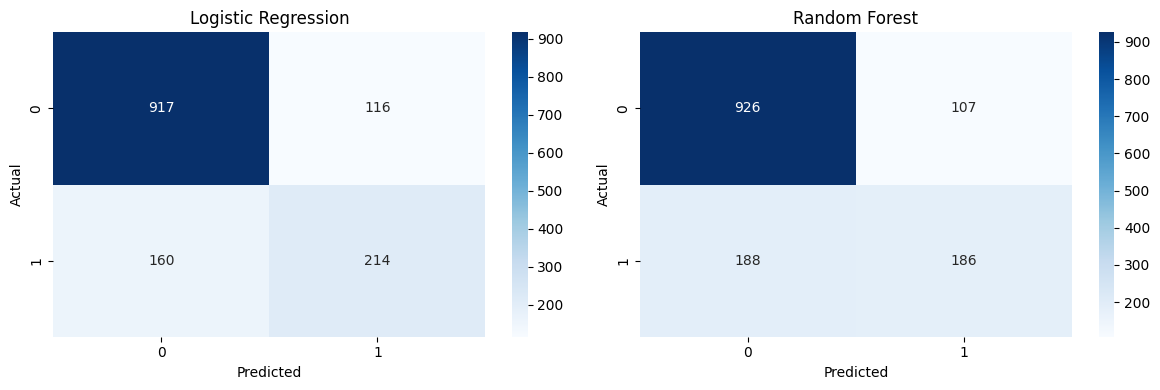

In [8]:
# confusion matrix for both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                            [lr_preds, rf_preds],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../src/models/confusion_matrices.png', dpi=150)
plt.show()

In [9]:
joblib.dump(lr, '../src/models/logistic_regression.pkl')
joblib.dump(rf, '../src/models/random_forest.pkl')

print("Models saved.")

Models saved.


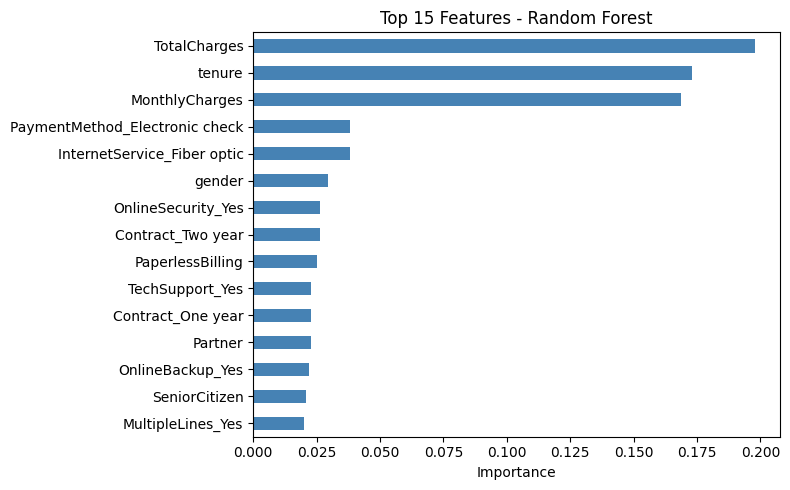

In [12]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, 
                        index=X_train.columns)

top15 = importances.sort_values(ascending=False).head(15)

top15.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 15 Features - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../src/models/feature_importance.png', dpi=150)
plt.show()

In [13]:
top15

TotalCharges                      0.197847
tenure                            0.172992
MonthlyCharges                    0.168765
PaymentMethod_Electronic check    0.038315
InternetService_Fiber optic       0.038273
gender                            0.029682
OnlineSecurity_Yes                0.026454
Contract_Two year                 0.026410
PaperlessBilling                  0.025129
TechSupport_Yes                   0.022907
Contract_One year                 0.022806
Partner                           0.022752
OnlineBackup_Yes                  0.022119
SeniorCitizen                     0.020922
MultipleLines_Yes                 0.020149
dtype: float64

Recall on class 1 means: of all customers who actually churned, how many did our model catch? Random Forest only caught 50% of real churners. It missed the other 50% entirely — predicted "won't churn" for them.

In a churn problem, a missed churner is expensive. A telecom company would rather call 100 customers with a retention offer and have 30 of them not actually be at risk, than miss 50 real churners and lose them forever. Missing a churner costs revenue. A false alarm just costs a phone call.

This is why recall on class 1 matters more than overall accuracy for this business problem. And it's exactly why Logistic Regression is our winner despite lower accuracy — it has higher ROC-AUC (0.836 vs 0.817) and better recall on churners (0.57 vs 0.50). Simpler model, better business outcome.